In [2]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
db = wrds.Connection()

Enter your WRDS username [魏泽渊]: zhizhou
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\魏泽渊\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [3]:
print("Problem: Analyze stock return and risk using WRDS CRSP data")

Problem: Analyze stock return and risk using WRDS CRSP data


In [15]:
query = """SELECT date, permno,ret FROM crsp.msf WHERE permno IN (14593, 10107, 93436) AND date BETWEEN '2020-01-01' AND '2025-12-30'"""
data = db.raw_sql(query)
print("\nRaw Data Preview:")
print(data.head())


Raw Data Preview:
         date  permno       ret
0  2020-01-31   10107  0.079455
1  2020-02-28   10107 -0.045292
2  2020-03-31   10107 -0.026542
3  2020-04-30   10107  0.136326
4  2020-05-29   10107  0.025389


In [10]:
data = data.dropna()
data['date'] = pd.to_datetime(data['date'])
returns = data.pivot(index='date', columns='permno', values='ret')
returns.columns = ['AAPL', 'MSFT', 'TSLA']
returns = returns.dropna()
print("\nSummary Statistics:")
print(returns.describe())


Summary Statistics:
           AAPL      MSFT      TSLA
count      60.0      60.0      60.0
mean   0.019291  0.024536  0.066933
std    0.064673  0.083526  0.221557
min   -0.109267 -0.122273 -0.367334
25%   -0.029067 -0.044449 -0.099596
50%    0.017225  0.026102  0.027194
75%    0.066372   0.09462   0.20202
max    0.176291  0.216309  0.741452


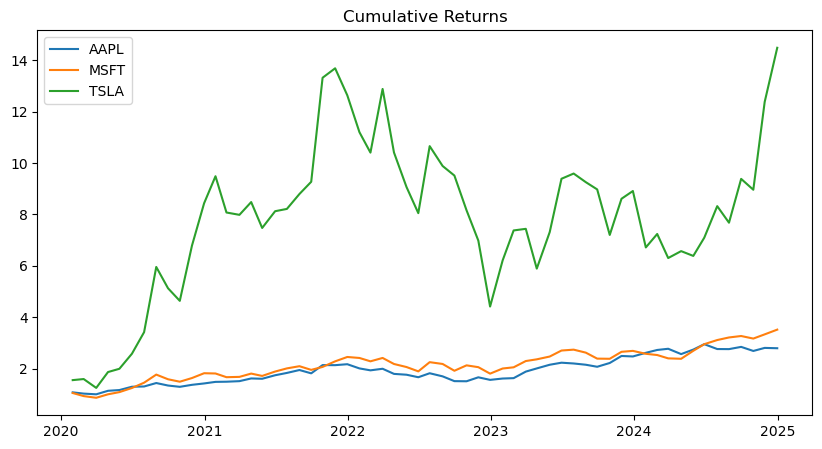

In [18]:
cum_returns = (1 + returns).cumprod()
plt.figure(figsize=(10,5))
for col in cum_returns.columns:
    plt.plot(cum_returns[col], label=col)
plt.title("Cumulative Returns")
plt.legend()
plt.show()

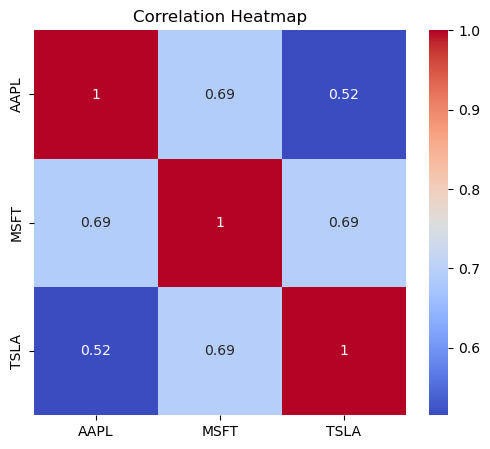

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [13]:
annual_return = returns.mean() * 12
annual_risk = returns.std() * (12 ** 0.5)
sharpe = annual_return / annual_risk
result = pd.DataFrame({ "Annual Return": annual_return,"Annual Risk": annual_risk,"Sharpe Ratio": sharpe})
print("\nRisk-Return Analysis:")
print(result)


Risk-Return Analysis:
      Annual Return  Annual Risk  Sharpe Ratio
AAPL       0.231487     0.224035      1.033263
MSFT       0.294426     0.289343      1.017569
TSLA       0.803196     0.767497      1.046513


In [17]:
print("\nInsights:")
print("- Tesla usually has highest risk and return")
print("- Apple and Microsoft are more stable")
print("- Diversification reduces risk")


Insights:
- Tesla usually has highest risk and return
- Apple and Microsoft are more stable
- Diversification reduces risk
